In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

The objective of this project is to analyze an online delivery dataset to understand delivery performance and customer satisfaction.

Add:
Which company provides the fastest delivery?
Does delivery time affect customer ratings?
Which city has the highest number of orders?
Do discounts improve customer satisfaction?

In [9]:
df=pd.read_csv(r"/content/drive/MyDrive/quick_commerce_data_raw (2).csv")

Here i had imported the file

In [11]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   Order_ID                 1000000 non-null  int64  
 1   Company                  1000000 non-null  object 
 2   City                     948000 non-null   object 
 3   Customer_Age             1000000 non-null  int64  
 4   Order_Value              1000000 non-null  float64
 5   Delivery_Time_Min        1000000 non-null  float64
 6   Distance_Km              1000000 non-null  float64
 7   Items_Count              965000 non-null   float64
 8   Product_Category         1000000 non-null  object 
 9   Payment_Method           1000000 non-null  object 
 10  Customer_Rating          953000 non-null   float64
 11  Discount_Applied         1000000 non-null  int64  
 12  Delivery_Partner_Rating  895863 non-null   float64
dtypes: float64(6), int64(3), object(4)
memory u

(1000000, 13)

Understand the data here

In [12]:
df.isnull().sum()

,0
Order_ID,0
Company,0
City,52000
Customer_Age,0
Order_Value,0
Delivery_Time_Min,0
Distance_Km,0
Items_Count,35000
Product_Category,0
Payment_Method,0


finding missing values and null vales

In [13]:
df.drop_duplicates(inplace=True)

Removed duplicates

In [14]:
df['Discount_Applied'] = df['Discount_Applied'].astype(int)

Fixed Data Types

In [15]:
df['City'] = df['City'].str.strip().str.title()

Fix City Names , Data was cleaned to ensure accuracy.

In [16]:
df.describe()

,Order_ID,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
count,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,965000.000000,953000.000000,1000000.000000,895863.000000
mean,1.500000e+06,38.470387,571.643584,16.452412,7.750231,9.998317,3.042072,0.400883,3.749257
std,2.886753e+05,12.118520,382.784520,6.257172,4.186665,5.478725,1.186872,0.490078,0.722121
min,1.000001e+06,18.000000,50.000000,5.000000,0.500000,1.000000,1.000000,0.000000,2.500000
25%,1.250001e+06,28.000000,287.840150,12.368000,4.130000,5.000000,2.000000,0.000000,3.100000
50%,1.500000e+06,38.000000,531.324600,16.342000,7.740000,10.000000,3.000000,0.000000,3.700000
75%,1.750000e+06,49.000000,796.182500,20.196000,11.380000,15.000000,4.000000,1.000000,4.400000
max,2.000000e+06,59.000000,13877.325000,40.000000,15.000000,19.000000,5.000000,1.000000,5.000000


<Axes: xlabel='Company'>

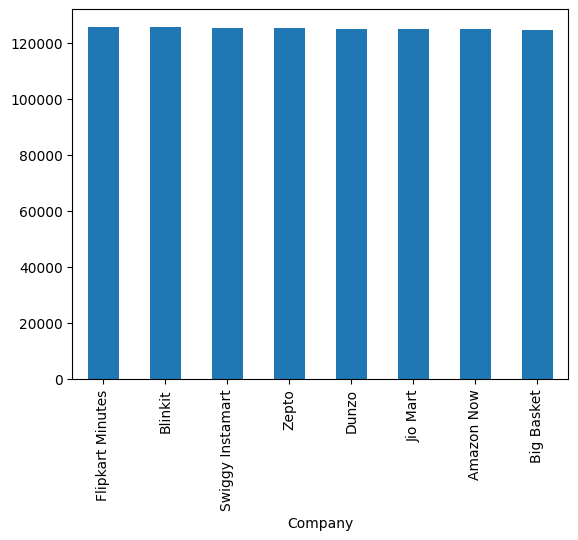

In [20]:
df['Company'].value_counts().plot(kind = "bar")


EDA(Exploratory Data Analysis) helps understand patterns and distributions.bold text

<Axes: xlabel='Company'>

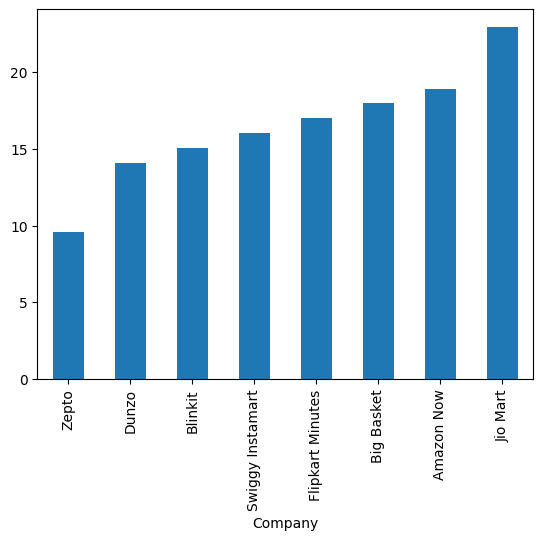

In [24]:
df.groupby('Company')['Delivery_Time_Min'].mean().sort_values().plot(kind='bar')

<Axes: xlabel='Company'>

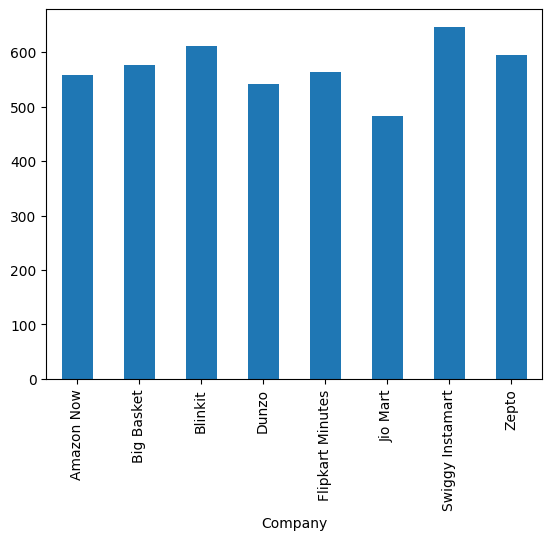

In [25]:
# Avg order value
df.groupby('Company')['Order_Value'].mean().plot(kind='bar')

In [ ]:
# Orders per city
df['City'].value_counts()

,count
City,
Hyderabad,83827
Kolkata,83528
Delhi,83520
Amritsar,83457
Gurgaon,83408
Mumbai,83372
Haridwar,83270
Jaipur,83237
Bengluru,83236


<Axes: ylabel='Order_Value'>

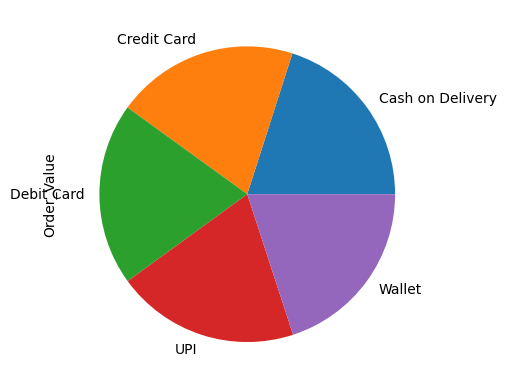

In [27]:
# Payment method
df.groupby('Payment_Method')["Order_Value"].mean().plot(kind = "pie")

In [ ]:
# Avg delivery time
df['Delivery_Time_Min'].mean()

np.float64(16.452411642000005)

In [ ]:
# Discount vs rating
df.groupby('Discount_Applied')['Customer_Rating'].mean()

,Customer_Rating
Discount_Applied,
0,3.043232
1,3.041588


There is no change in customer rating after applying discount.

In [30]:
# Product category
df.groupby('Product_Category')["Order_Value"].sum()

,Order_Value
Product_Category,
Beverages,8.136886e+07
Dairy,8.243549e+07
Fruits & Vegetables,8.116218e+07
Groceries,8.188473e+07
Household,8.185880e+07
Personal Care,8.134025e+07
Snacks,8.159326e+07


The order vale of all products remains same

In [ ]:
# Distance vs time
df[['Distance_Km','Delivery_Time_Min']].corr()

,Distance_Km,Delivery_Time_Min
Distance_Km,1.000000,0.386376
Delivery_Time_Min,0.386376,1.000000


In [ ]:
# Best company
df.groupby('Company')['Customer_Rating'].mean()

,Customer_Rating
Company,
Amazon Now,2.912955
Big Basket,3.099230
Blinkit,3.530672
Dunzo,2.481066
Flipkart Minutes,3.016538
Jio Mart,2.827445
Swiggy Instamart,3.274076
Zepto,3.195669


In [ ]:
# Top 5 orders
df.nlargest(5, 'Order_Value')

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
348927,1348928,Flipkart Minutes,Chennai,29,13877.32500,17.070,8.45,1.0,Household,UPI,3.7,1,2.5
670358,1670359,Zepto,Kolkata,21,13405.62825,11.378,10.63,19.0,Fruits & Vegetables,Cash on Delivery,1.6,1,4.9
36263,1036264,Flipkart Minutes,Noida,31,13180.90500,14.584,2.64,13.0,Groceries,UPI,2.7,1,3.9
317289,1317290,Swiggy Instamart,Gurgaon,41,12364.76175,17.848,13.08,10.0,Fruits & Vegetables,Credit Card,3.8,1,4.3
998609,1998610,Big Basket,Pune,54,11466.34020,14.936,1.56,19.0,Household,UPI,3.9,1,4.6


In [ ]:
# Age groups
df['Age_Group'] = pd.cut(df['Customer_Age'],
                        bins=[18,25,35,50,70],
                        labels=['18-25','26-35','36-50','50+'])
df.groupby('Age_Group')['Order_Value'].mean()

/tmp/ipykernel_6523/586967304.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_Group')['Order_Value'].mean()


,Order_Value
Age_Group,
18-25,572.154254
26-35,571.138719
36-50,571.614590
50+,571.654786


In [ ]:
# Correlations
df.corr(numeric_only=True)

,Order_ID,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
Order_ID,1.000000,0.001084,0.000167,-0.000906,-0.001328,0.000946,0.001354,-0.000982,0.000820
Customer_Age,0.001084,1.000000,0.000112,0.000556,0.001863,-0.001496,-0.002068,0.001905,0.002004
Order_Value,0.000167,0.000112,1.000000,-0.120885,0.000787,-0.001594,0.027357,0.302487,-0.000444
Delivery_Time_Min,-0.000906,0.000556,-0.120885,1.000000,0.386376,0.000167,-0.041509,-0.000232,-0.001223
Distance_Km,-0.001328,0.001863,0.000787,0.386376,1.000000,0.001290,-0.000376,0.000343,0.001633
Items_Count,0.000946,-0.001496,-0.001594,0.000167,0.001290,1.000000,-0.001108,0.001523,0.000713
Customer_Rating,0.001354,-0.002068,0.027357,-0.041509,-0.000376,-0.001108,1.000000,-0.000679,0.001442
Discount_Applied,-0.000982,0.001905,0.302487,-0.000232,0.000343,0.001523,-0.000679,1.000000,-0.001042
Delivery_Partner_Rating,0.000820,0.002004,-0.000444,-0.001223,0.001633,0.000713,0.001442,-0.001042,1.000000


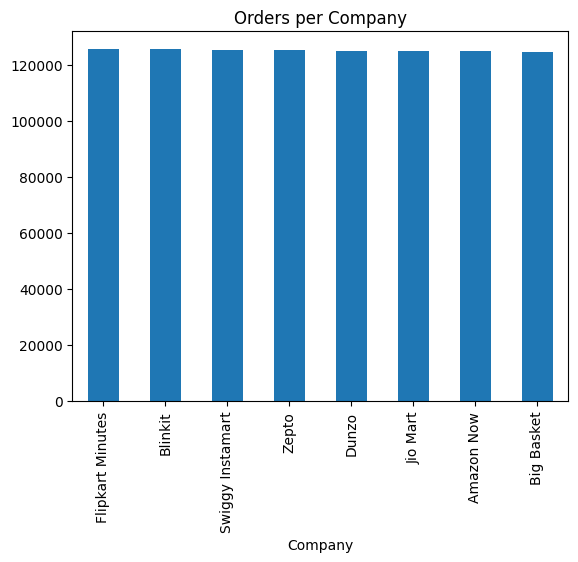

In [ ]:
df['Company'].value_counts().plot(kind='bar')
plt.title("Orders per Company")
plt.show()

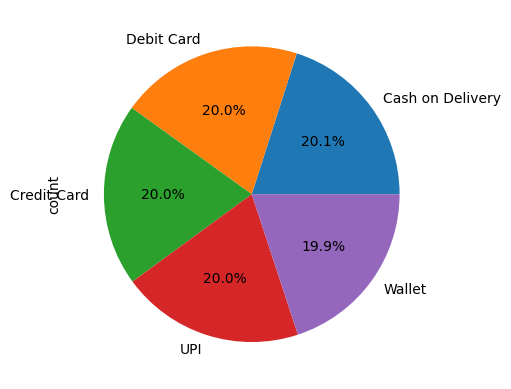

In [ ]:
df['Payment_Method'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.show()

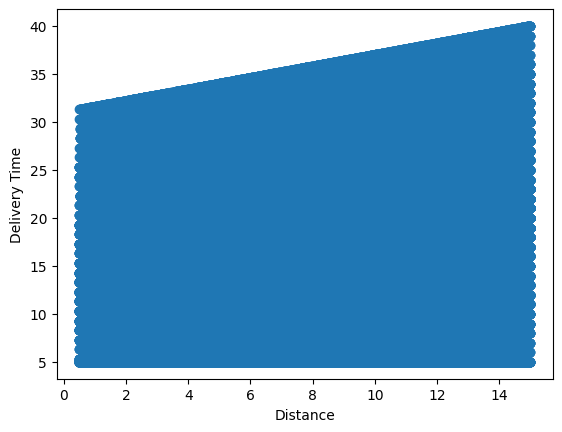

In [ ]:
plt.plot(df['Distance_Km'], df['Delivery_Time_Min'], 'o')
plt.xlabel("Distance")
plt.ylabel("Delivery Time")
plt.show()

**Key Insights **

The analysis shows that faster delivery generally leads to higher customer ratings, indicating that delivery speed is a key factor in customer satisfaction. It was also observed that delivery time increases with distance, showing a strong relationship between distance and delivery efficiency. Some companies consistently perform better than others in terms of customer ratings, suggesting higher service quality. Additionally, discounts do not significantly improve customer ratings, meaning that reducing price alone does not guarantee customer satisfaction. Certain cities have a higher number of orders, indicating greater demand in those areas. Furthermore, middle-aged customers tend to spend more compared to other age groups.

Conclusion

In conclusion, this project highlights that delivery speed and service quality are the most important factors affecting customer satisfaction. Distance plays a major role in increasing delivery time, while discounts have only a limited impact on improving ratings. Some companies perform better due to better service quality. Therefore, companies should focus on improving delivery efficiency, optimizing operations for long-distance deliveries, and enhancing overall customer experience to achieve better performance.